# Pakistan NIH Surveillance Data

This notebook demonstrates how to access disease surveillance data from the **Pakistan National Institute of Health (NIH)** Integrated Disease Surveillance and Response (IDSR) system.

**Data Sources:**
- **IDSR Weekly Bulletins** - Weekly disease surveillance reports (priority diseases)
- **Provincial Reports** - Province and district-level surveillance data
- **Seasonal Awareness and Alert Letters (SAAL)** - Seasonal disease alerts
- **Advisories** - Public health advisories

**Coverage:**
- **Geographic**: All 4 provinces + Islamabad Capital Territory + Azad Kashmir + Gilgit-Baltistan
- **Diseases**: 30+ priority diseases including Dengue, Malaria, Typhoid, Hepatitis, COVID-19
- **Frequency**: Weekly bulletins, annual reports

**Requirements:**
```bash
pip install pandas matplotlib seaborn requests beautifulsoup4 pypdf pdfplumber geopandas
```

## 1. Setup and Imports

In [1]:
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
%matplotlib inline

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

from epidatasets.sources.pakistan_nih import PakistanNIHAccessor

print('Imports completed successfully!')
print(f'Current time: {datetime.now().strftime("%Y-%m-%d %H:%M")}')

Imports completed successfully!
Current time: 2026-05-23 18:14


## 2. Initialize Accessor

In [2]:
nih = PakistanNIHAccessor()

print('Pakistan NIH Accessor initialized')
print(f'Source: {nih.source_name}')
print(f'Portal: {nih.source_url}')
print(f'Provinces: {len(nih.PROVINCES)}')
print(f'Priority diseases: {len(nih.PRIORITY_DISEASES)}')

Pakistan NIH Accessor initialized
Source: pakistan_nih
Portal: https://phb.nih.org.pk/integratedisease-surveillance-and-response
Provinces: 7
Priority diseases: 13


## 3. Map of Provinces and Territories

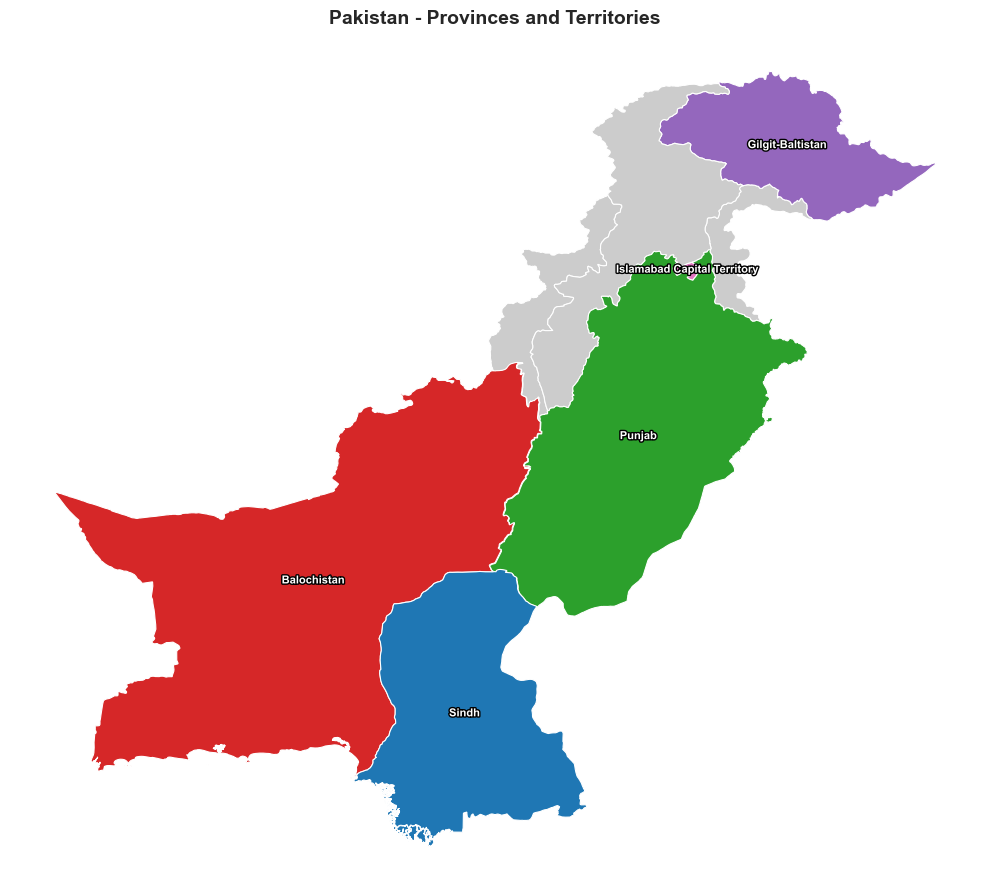

In [3]:
import geopandas as gpd

pak = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_PAK_1.json')

province_name_map = {
    'Punjab': 'Punjab',
    'Sindh': 'Sindh',
    'Khyber Pakhtunkhwa': 'Khyber Pakhtunkhwa',
    'Balochistan': 'Balochistan',
    'Gilgit-Baltistan': 'Gilgit-Baltistan',
    'Azad Jammu and Kashmir': 'Azad Kashmir',
    'Islamabad Capital Territory': 'Islamabad',
}

fig, ax = plt.subplots(figsize=(10, 12))
colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728', '#9467bd', '#8c564b', '#e377c2']
for idx, row in pak.iterrows():
    matched = None
    for prov, gadm in province_name_map.items():
        if gadm.lower() in row['NAME_1'].lower():
            matched = prov
            break
    if matched:
        color = colors[nih.PROVINCES.index(matched) % len(colors)]
        pak.iloc[[idx]].plot(ax=ax, color=color, edgecolor='white', linewidth=0.8)
        ax.annotate(
            matched,
            xy=(row.geometry.centroid.x, row.geometry.centroid.y),
            ha='center', va='center', fontsize=8, fontweight='bold', color='white',
            path_effects=[pe.withStroke(linewidth=2, foreground='black')],
        )
    else:
        pak.iloc[[idx]].plot(ax=ax, color='#cccccc', edgecolor='white', linewidth=0.8)

ax.set_title('Pakistan - Provinces and Territories', fontsize=14, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 4. Discover Available Bulletins

Available bulletins: 122


,year,week,url,title,status
0,2026,18,https://phb.nih.org.pk/wp-content/uploads/2026...,IDSRS Week 18 Bulletin (2026),available
1,2026,17,https://phb.nih.org.pk/wp-content/uploads/2026...,IDSRS Week 17 Bulletin (2026),available
2,2026,16,https://phb.nih.org.pk/wp-content/uploads/2026...,IDSRS Week 16 Bulletin (2026),available
3,2026,15,https://phb.nih.org.pk/wp-content/uploads/2026...,IDSRS Week 15 Bulletin (2026),available
4,2026,14,https://phb.nih.org.pk/wp-content/uploads/2026...,IDSRS Week 14 Bulletin (2026),available
5,2026,13,https://phb.nih.org.pk/wp-content/uploads/2026...,IDSRS Week 13 Bulletin (2026),available
6,2026,12,https://phb.nih.org.pk/wp-content/uploads/2026...,IDSRS Week 12 Bulletin (2026),available
7,2026,11,https://phb.nih.org.pk/wp-content/uploads/2026...,IDSRS Week 11 Bulletin (2026),available
8,2026,10,https://phb.nih.org.pk/wp-content/uploads/2026...,IDSRS Week 10 Bulletin (2026),available
9,2026,9,https://phb.nih.org.pk/wp-content/uploads/2026...,IDSRS Week 09 Bulletin (2026),available


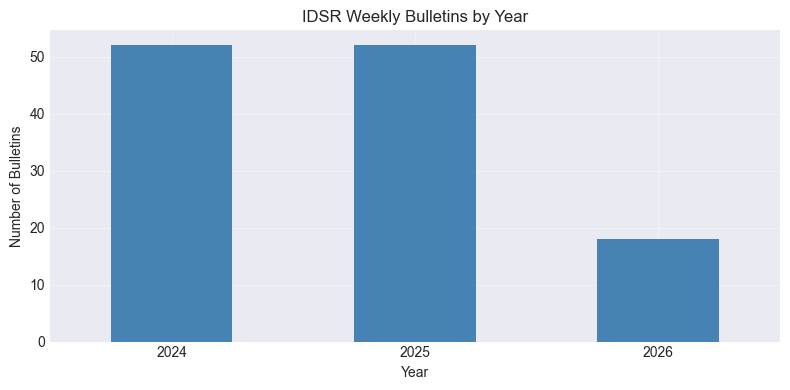

In [4]:
bulletins = nih.list_available_bulletins(start_year=2024, end_year=2026)
available = bulletins[bulletins['status'] == 'available']
print(f'Available bulletins: {len(available)}')
display(available.head(10))

if not available.empty:
    yearly = available.groupby('year').size()
    fig, ax = plt.subplots(figsize=(8, 4))
    yearly.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_xlabel('Year')
    ax.set_ylabel('Number of Bulletins')
    ax.set_title('IDSR Weekly Bulletins by Year')
    ax.tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.show()

## 5. Download a Bulletin and Extract Structured Data

The `get_bulletin_data()` method downloads a bulletin PDF and automatically extracts all structured tables, including:
- **Provincial summary** (Table 1): Disease counts by province
- **District tables** (Tables 2-4): Disease counts by district for Sindh, Balochistan, and KP
- **Lab-confirmed cases** (Table 5): Testing and positive counts by province
- **Compliance data** (Tables 6-7): Reporting site compliance rates

If the live PDF is unavailable (server issues, broken links), sample data is used as fallback.

In [5]:
# Try the most recent available bulletin, fall back to sample data
data = {}
if not available.empty:
    for _, row in available.head(5).iterrows():
        attempt = nih.get_bulletin_data(year=row['year'], week=row['week'])
        if attempt:
            data = attempt
            print(f"Downloaded: week {row['week']}, {row['year']}")
            break

if not data:
    print("Live PDF unavailable - using sample data for demonstration.")
    data = nih.get_sample_bulletin_data()

print(f'Extracted table types: {list(data.keys())}')
for key, df in data.items():
    print(f'  {key}: {len(df)} rows x {len(df.columns)} cols')

Failed to download bulletin: 404 Client Error: Not Found for url: https://phb.nih.org.pk/wp-content/uploads/2026/05/IDSRS%20Weekly%20Report-18-NG%20(1).pdf
Failed to download bulletin: 404 Client Error: Not Found for url: https://phb.nih.org.pk/wp-content/uploads/2026/05/Weekly%20Report-17-2026.pdf
Failed to download bulletin: 404 Client Error: Not Found for url: https://phb.nih.org.pk/wp-content/uploads/2026/05/IDSRS%20Weekly%20Report-16-2026%20-%20NG%20(1).pdf
Failed to download bulletin: 404 Client Error: Not Found for url: https://phb.nih.org.pk/wp-content/uploads/2026/05/Weekly%20Report-15-2026%20.pdf
Failed to download bulletin: 404 Client Error: Not Found for url: https://phb.nih.org.pk/wp-content/uploads/2026/05/Weekly%20Report-14-2026.pdf


Live PDF unavailable - using sample data for demonstration.
Extracted table types: ['provincial_summary', 'lab_confirmed', 'compliance', 'district_Sindh', 'district_Khyber Pakhtunkhwa']
  provincial_summary: 10 rows x 8 cols
  lab_confirmed: 7 rows x 4 cols
  compliance: 8 rows x 5 cols
  district_Sindh: 10 rows x 3 cols
  district_Khyber Pakhtunkhwa: 10 rows x 3 cols


## 6. Provincial Summary - Disease Distribution

,disease,Punjab,Sindh,Khyber Pakhtunkhwa,Balochistan,Gilgit-Baltistan,Azad Jammu and Kashmir,Islamabad Capital Territory
0,Malaria,2450,3120,890,1340,45,120,78
1,Dengue Fever,560,890,210,55,5,15,42
2,COVID-19,120,95,45,20,8,12,30
3,Typhoid Fever,340,520,110,85,12,25,18
4,Hepatitis,280,410,95,70,8,20,15
5,Measles,90,130,55,40,3,8,5
6,Tuberculosis,450,380,120,65,10,15,22
7,Crimean-Congo Hemorrhagic Fever (CCHF),15,8,22,35,2,1,3
8,Leishmaniasis,25,45,10,120,1,2,1
9,Seasonal Influenza,180,150,90,35,8,12,25


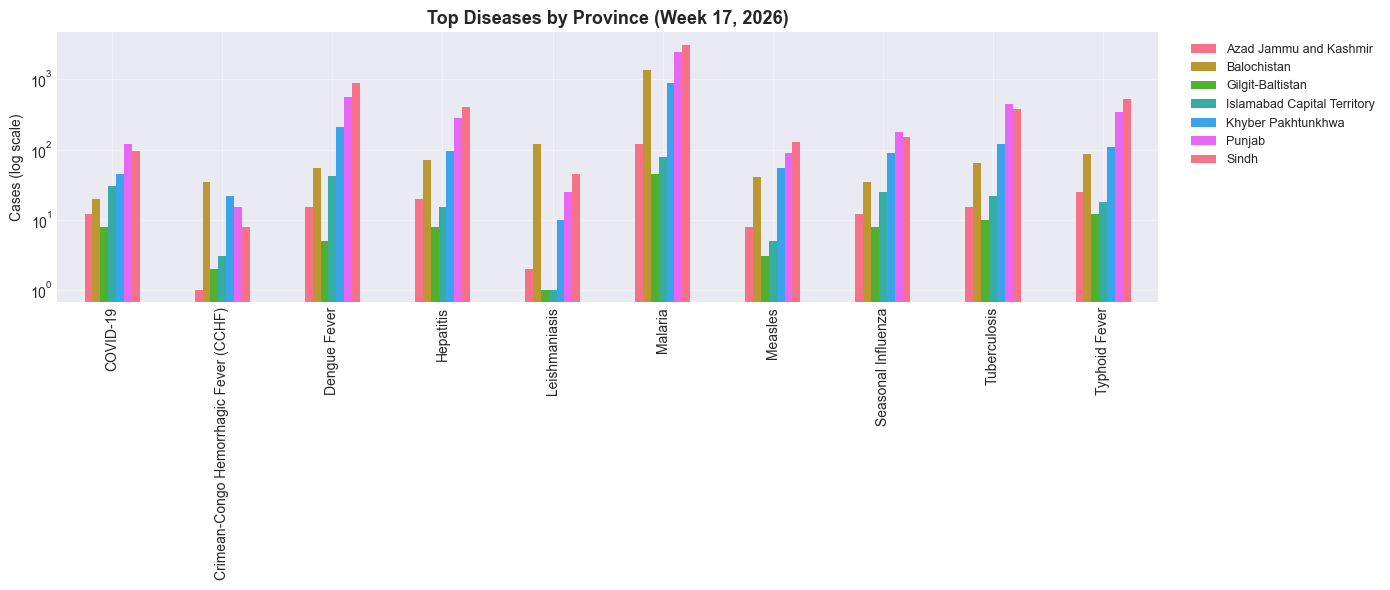

In [6]:
if 'provincial_summary' in data:
    summary = data['provincial_summary']
    display(summary.head(10))

    top_diseases = summary.drop(columns=['week', 'year'], errors='ignore').head(10)
    disease_cols = [c for c in top_diseases.columns if c != 'disease']
    melt = top_diseases.melt(id_vars='disease', value_vars=disease_cols, var_name='Province', value_name='Cases')
    melt = melt.dropna(subset=['Cases'])

    fig, ax = plt.subplots(figsize=(14, 6))
    melt.pivot(index='disease', columns='Province', values='Cases').plot(
        kind='bar', ax=ax, logy=True
    )
    ax.set_title('Top Diseases by Province (Week 17, 2026)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Cases (log scale)')
    ax.set_xlabel('')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()

## 7. District-Level Data - Sindh

disease,Dengue Fever,Hepatitis,Malaria,Measles,Typhoid Fever
district,,,,,
Hyderabad,180.0,NaN,420.0,NaN,NaN
Karachi,520.0,180.0,890.0,65.0,245.0
Larkana,NaN,95.0,NaN,NaN,NaN
Thatta,NaN,NaN,310.0,NaN,120.0


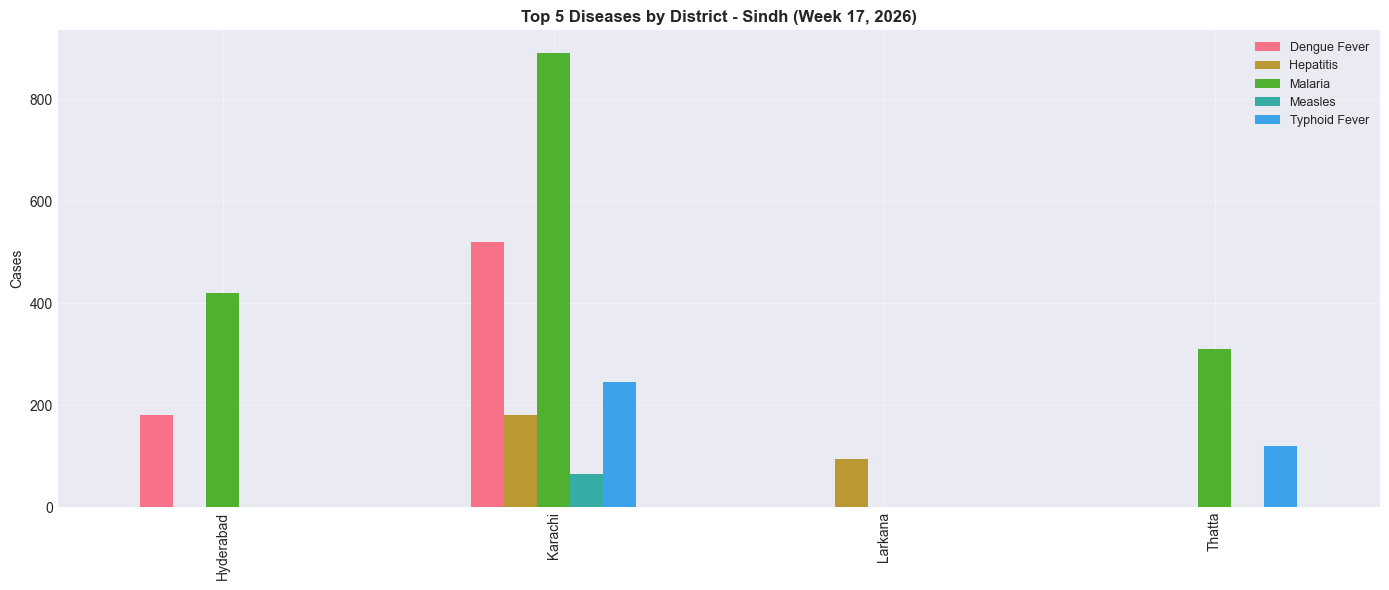

In [7]:
sindh_key = [k for k in data if 'district_Sindh' in k]
if sindh_key:
    sindh = data[sindh_key[0]]
    top5 = sindh.groupby('disease')['cases'].sum().nlargest(5).index
    sindh_top = sindh[sindh['disease'].isin(top5)]

    pivot = sindh_top.pivot_table(index='district', columns='disease', values='cases', aggfunc='sum')
    display(pivot.head(10))

    fig, ax = plt.subplots(figsize=(14, 6))
    pivot.head(15).plot(kind='bar', ax=ax)
    ax.set_title('Top 5 Diseases by District - Sindh (Week 17, 2026)', fontweight='bold')
    ax.set_ylabel('Cases')
    ax.set_xlabel('')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

## 8. District-Level Data - Khyber Pakhtunkhwa

disease,Dengue Fever,Hepatitis,Malaria,Tuberculosis,Typhoid Fever
district,,,,,
Mardan,NaN,NaN,145.0,NaN,NaN
Peshawar,95.0,35.0,220.0,48.0,42.0
Swat,55.0,NaN,110.0,NaN,NaN


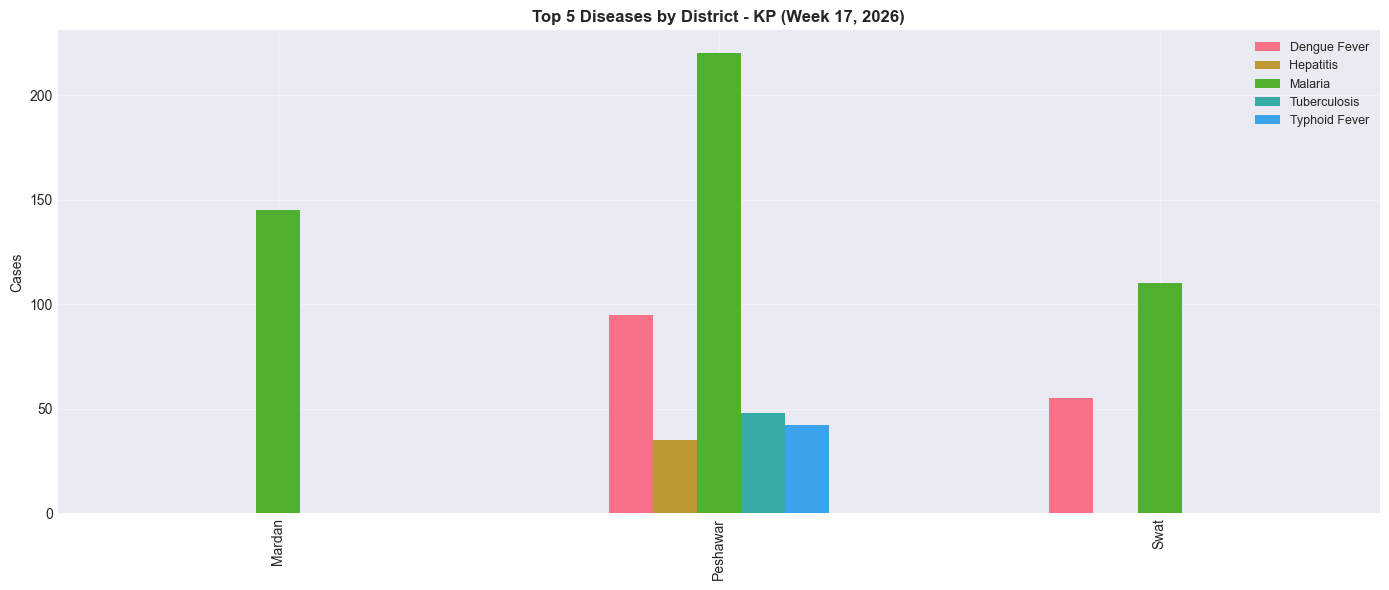

In [8]:
kp_key = [k for k in data if 'district_Khyber' in k]
if kp_key:
    kp = data[kp_key[0]]
    top5 = kp.groupby('disease')['cases'].sum().nlargest(5).index
    kp_top = kp[kp['disease'].isin(top5)]

    pivot = kp_top.pivot_table(index='district', columns='disease', values='cases', aggfunc='sum')
    display(pivot.head(10))

    fig, ax = plt.subplots(figsize=(14, 6))
    pivot.head(15).plot(kind='bar', ax=ax)
    ax.set_title('Top 5 Diseases by District - KP (Week 17, 2026)', fontweight='bold')
    ax.set_ylabel('Cases')
    ax.set_xlabel('')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

## 9. Cross-Province Comparison

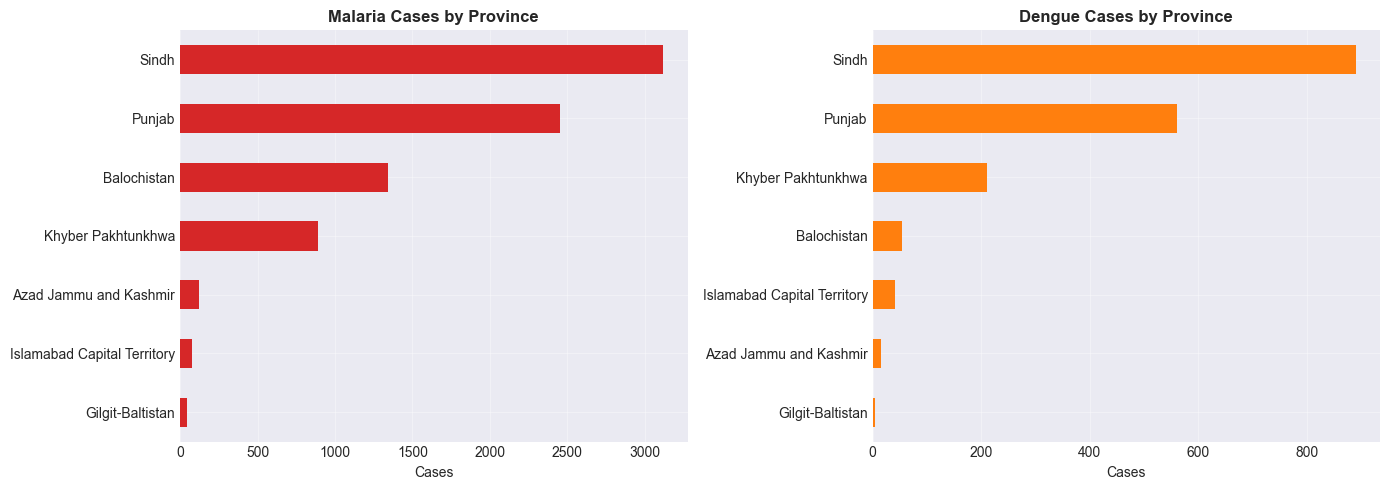

In [9]:
if 'provincial_summary' in data:
    summary = data['provincial_summary']
    plot_cols = [c for c in summary.columns if c not in ('disease', 'week', 'year')]
    malaria = summary[summary['disease'].str.contains('Malaria', case=False)]
    dengue = summary[summary['disease'].str.contains('Dengue', case=False)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    if not malaria.empty:
        vals = malaria[plot_cols].iloc[0]
        vals = vals.dropna().sort_values(ascending=True)
        vals.plot(kind='barh', ax=axes[0], color='#d62728')
        axes[0].set_title('Malaria Cases by Province', fontweight='bold')
        axes[0].set_xlabel('Cases')

    if not dengue.empty:
        vals = dengue[plot_cols].iloc[0]
        vals = vals.dropna().sort_values(ascending=True)
        vals.plot(kind='barh', ax=axes[1], color='#ff7f0e')
        axes[1].set_title('Dengue Cases by Province', fontweight='bold')
        axes[1].set_xlabel('Cases')

    plt.tight_layout()
    plt.show()

## 10. Compliance Reporting

,province,district,total_sites,reported_sites,compliance_rate
0,Punjab,Lahore,45,40,89
1,Punjab,Faisalabad,32,27,84
2,Sindh,Karachi,38,35,92
3,Sindh,Hyderabad,22,18,82
4,Khyber Pakhtunkhwa,Peshawar,28,23,82
5,Balochistan,Quetta,18,14,78
6,Gilgit-Baltistan,Gilgit,12,10,83
7,Islamabad Capital Territory,Islamabad,15,14,93


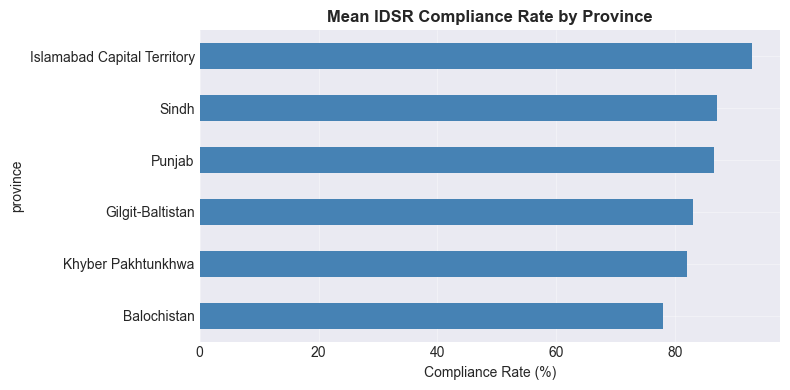

In [10]:
if 'compliance' in data:
    comp = data['compliance']
    display(comp.head(10))

    if 'compliance_rate' in comp.columns:
        by_province = comp.groupby('province')['compliance_rate'].mean().dropna().sort_values()
        if not by_province.empty:
            fig, ax = plt.subplots(figsize=(8, 4))
            by_province.plot(kind='barh', ax=ax, color='steelblue')
            ax.set_title('Mean IDSR Compliance Rate by Province', fontweight='bold')
            ax.set_xlabel('Compliance Rate (%)')
            plt.tight_layout()
            plt.show()

## 11. Seasonal Alerts and Advisories

In [11]:
try:
    saals = nih.get_saals()
    print(f'Seasonal Awareness and Alert Letters: {len(saals)} found')
    if not saals.empty:
        display(saals.head(5))
except Exception as e:
    print(f'Could not fetch SAALs: {e}')

Seasonal Awareness and Alert Letters: 45 found


,title,url,season,diseases
0,SAAL,https://phb.nih.org.pk/saal,None,None
1,"Seasonal Awareness and Alert Letter (SAAL), 61...",https://www.nih.org.pk/wp-content/uploads/2025...,None,Seasonal Influenza
2,Download,https://www.nih.org.pk/wp-content/uploads/2025...,None,None
3,"Seasonal Awareness and Alert Letter (SAAL), 59...",https://www.nih.org.pk/wp-content/uploads/2024...,None,Seasonal Influenza
4,Download,https://www.nih.org.pk/wp-content/uploads/2024...,None,None


In [12]:
try:
    advisories = nih.get_advisories()
    print(f'Public Health Advisories: {len(advisories)} found')
    if not advisories.empty:
        display(advisories.head(5))
except Exception as e:
    print(f'Could not fetch advisories: {e}')

Public Health Advisories: 90 found


,title,url,date
0,+92 (51) 9255110,tel:+92 (51) 9255110,None
1,+92 (51) 9255112-4,tel:+92 (51) 9255112,None
2,Home,https://phb.nih.org.pk/home,None
3,About Us,https://phb.nih.org.pk,None
4,Who We Are,https://phb.nih.org.pk/about-us,None


## 12. Summary

This notebook demonstrated the `PakistanNIHAccessor` capabilities:

- **Bulletin discovery**: Scrape available bulletins from the NIH portal (no URL guessing)
- **Structured data extraction**: Automatically parse provincial summaries, district-level data, lab-confirmed cases, and compliance tables from PDF bulletins
- **Visualization**: Provincial maps, disease comparisons, district-level breakdowns
- **Alerts**: Access to SAALs and advisories

**Documentation:**
- **NIH Portal**: https://phb.nih.org.pk/
- **IDSR Weekly**: https://phb.nih.org.pk/integratedisease-surveillance-and-response
- **Repository**: https://github.com/fccoelho/epidemiological-datasets